# Hospital Patient Flow Demand Analysis¶
### Third Notebook: Demand Forecasting and Operational Uncertainty Modeling

This third phase focuses on modeling hospital demand patterns and quantifying operational uncertainty through time series analysis.

The objective is to develop forecasting models capable of predicting patient demand over different time horizons while identifying temporal variations in hospital activity.

Using the operational datasets created in the previous phase, time series methods are applied to analyze demand evolution, detect recurring patterns, and generate demand forecasts.

The analysis focuses on selecting appropriate forecasting techniques, evaluating model performance, and quantifying forecasting uncertainty to better understand demand dynamics.

The overall goal is to transform historical patient flow data into forward-looking demand information that can support healthcare planning and operational decision-making.

**Author:** J-F J  
**Date:** July 2026  
**Dataset:** Healthcare Analytics Patient Flow Data (Kaggle)

## 1-Data Loading and Overview

In [1]:
import pandas as pd
import sys
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

file_path = "/kaggle/input/datasets/jfjutras07/hospital-operational-datasets/hospital_operational_datasets.xlsx"

xls = pd.ExcelFile(file_path)
sheet_names = [s for s in xls.sheet_names if s != "Lists"]

dataframes = {}

for sheet in sheet_names:
    dataframes[sheet] = pd.read_excel(xls, sheet_name=sheet)

overview = pd.DataFrame({
    "table_name": sheet_names,
    "n_rows": [dataframes[s].shape[0] for s in sheet_names],
    "n_cols": [dataframes[s].shape[1] for s in sheet_names]
})

overview

,table_name,n_rows,n_cols
0,Patient Features,9216,19
1,Daily Demand,579,2
2,Hourly Demand,24,2
3,Department Shift Demand,21,3
4,Workforce Structure,7,6
5,Workforce Costs,5,2
6,Workforce Schedule,5,5


In [2]:
# Load custom library from GitHub
!rm -rf /kaggle/working/jfj-utils
!git clone https://github.com/jfjutras07/jfj-utils.git

# Add to Python path
sys.path.append("/kaggle/working/jfj-utils")

Cloning into 'jfj-utils'...
remote: Enumerating objects: 3901, done.
remote: Counting objects: 100% (330/330), done.
remote: Compressing objects: 100% (184/184), done.
remote: Total 3901 (delta 272), reused 146 (delta 146), pack-reused 3571 (from 3)
Receiving objects: 100% (3901/3901), 1.30 MiB | 17.68 MiB/s, done.
Resolving deltas: 100% (2565/2565), done.


## 2-Time Series Validation

In [3]:
# Extract dataset required for time series forecasting
df_daily_demand = dataframes["Daily Demand"]

from eda.describe_structure import describe_time_structure
describe_time_structure(
    df_daily_demand,
    date_col="Admission Date",
    value_col="Patient Volume"
)


=== Time Series Overview ===

                observations start_date   end_date expected_frequency  \
Patient Volume         579.0 2023-04-01 2024-10-30                  D   

                time_span_days  
Patient Volume           579.0  

=== Timestamp Quality ===

                duplicate_timestamps  missing_timestamps  missing_values  \
Admission Date                   0.0                 0.0             0.0   

               is_sorted  
Admission Date      True  

=== Series Statistics ===

                count       mean       std  min   25%   50%   75%   max  \
Patient Volume  579.0  15.917098  3.726836  7.0  13.0  16.0  18.0  30.0   

                missing_values  zero_values  negative_values  \
Patient Volume               0            0                0   

                coefficient_variation  
Patient Volume                0.23414  

=== Ready for Forecasting ===

Time series passed all structural validation checks.


## 3-Time Series Characteristics

**Seasonal Pattern Assessment**

Seasonal patterns are assessed to determine whether hospital demand follows recurring temporal cycles, such as weekly variations. This information will guide the selection of appropriate forecasting models and seasonal components.

In [4]:
from eda.stats_time import seasonal_strength_test

seasonality_result = seasonal_strength_test(
    df_daily_demand,
    date_col="Admission Date",
    value_col="Patient Volume",
    period=7
)

seasonality_result

{'Seasonal Period': 7,
 'Seasonal Variance': 3.5632135791519497,
 'Residual Variance': 9.057234633711309,
 'Seasonal Strength': 0.2719153255831245,
 'Interpretation': 'Weak or no seasonal pattern',
 'Observations': 579}

**Stationarity Assessment**

In [5]:
from eda.stats_time import adf_stationarity_test

stationarity_result = adf_stationarity_test(
    df_daily_demand,
    date_col="Admission Date",
    value_col="Patient Volume"
)

stationarity_result

{'ADF Statistic': np.float64(-24.094331036147768),
 'p-value': 0.0,
 'Critical Value 1%': np.float64(-3.441714324024304),
 'Critical Value 5%': np.float64(-2.8665533998436215),
 'Critical Value 10%': np.float64(-2.5694399997605393),
 'Stationary': True,
 'Conclusion': 'Series is stationary',
 'Observations': 579}

**Autocorrelation Assessment**

Autocorrelation is evaluated to determine whether past demand values contain meaningful information about future observations. This helps identify whether temporal dependencies can be exploited by forecasting models.

In [6]:
from eda.stats_time import ljung_box_test

autocorrelation_result = ljung_box_test(
    df_daily_demand,
    date_col="Admission Date",
    value_col="Patient Volume",
    lags=10
)

autocorrelation_result

{'Lag': 10,
 'Ljung-Box Statistic': np.float64(9.919550988018582),
 'p-value': np.float64(0.4475795328248331),
 'Autocorrelation Detected': np.False_,
 'Conclusion': 'No significant autocorrelation detected',
 'Observations': 579}

The time series assessment indicates that hospital daily demand is relatively stable, with weak seasonal patterns and no significant autocorrelation. The series is stationary, suggesting that standard forecasting approaches can be applied without extensive preprocessing or complex temporal adjustments. These characteristics support the evaluation of both baseline and advanced forecasting models in the next phase.

**Autocorrelation Structure Analysis**

Autocorrelation and partial autocorrelation plots are examined to identify potential temporal dependencies and guide the selection of forecasting model structures. These diagnostics complement statistical tests by showing the contribution of specific time lags.

The ACF and PACF plots show limited autocorrelation across lag values, with no dominant temporal dependency pattern identified. These results confirm the previous statistical assessment and support the evaluation of relatively simple forecasting approaches before considering more complex models.

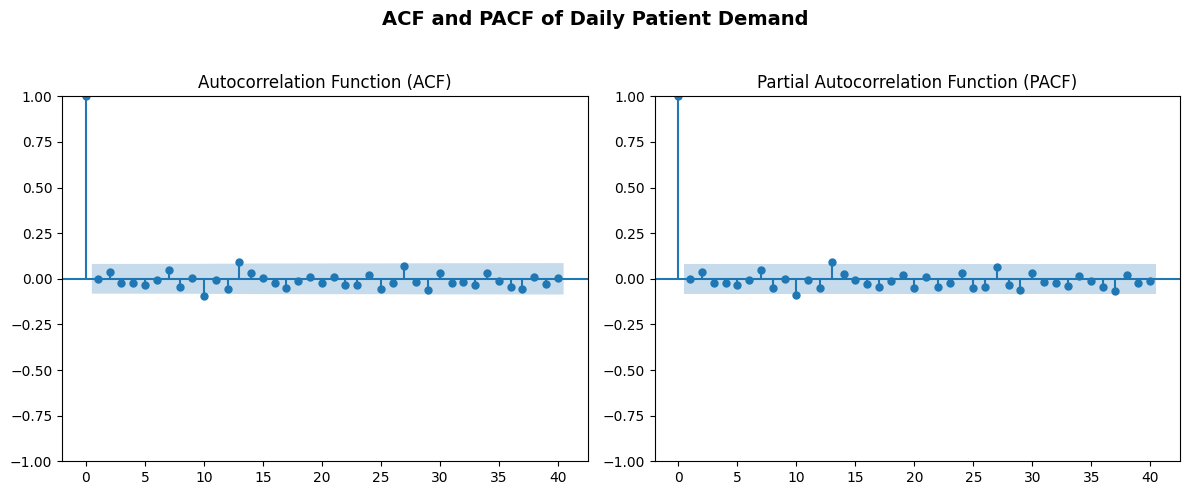

In [7]:
from visualization.explore_time import plot_acf_pacf

plot_acf_pacf(
    df_daily_demand,
    value_col="Patient Volume",
    lags=40,
    title="ACF and PACF of Daily Patient Demand"
)

The ACF and PACF analysis identified only two significant lag relationships among the first 40 tested lags (lags 10 and 13), with no clear recurring seasonal pattern. These results confirm the limited temporal dependency observed in previous statistical tests and support the evaluation of relatively simple forecasting approaches.

## 4-Forecasting Models

Forecasting models are developed using a sequential evaluation strategy, starting with simple benchmark approaches and progressively testing more advanced methods. This approach ensures that model complexity is justified by measurable improvements in predictive performance.

**Temporal Train-Test Split**

In [8]:
# Ensure chronological ordering
df_daily_demand = (
    df_daily_demand
    .sort_values("Admission Date")
    .copy()
)

# Define train-test split
split_point = int(len(df_daily_demand) * 0.8)

train_df = df_daily_demand.iloc[:split_point].copy()
test_df = df_daily_demand.iloc[split_point:].copy()


# Convert to time series format required by forecasting models
train = (
    train_df
    .set_index("Admission Date")["Patient Volume"]
)

test = (
    test_df
    .set_index("Admission Date")["Patient Volume"]
)


print(f"Training period: {train.index.min()} to {train.index.max()}")
print(f"Testing period: {test.index.min()} to {test.index.max()}")

print(f"\nTraining observations: {len(train)}")
print(f"Testing observations: {len(test)}")

print("\nData types:")
print(type(train))
print(type(test))

Training period: 2023-04-01 00:00:00 to 2024-07-06 00:00:00
Testing period: 2024-07-07 00:00:00 to 2024-10-30 00:00:00

Training observations: 463
Testing observations: 116

Data types:
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


The temporal split preserves the chronological structure of the demand series, with 463 observations used for model training and 116 observations reserved for out-of-sample evaluation. This approach simulates real forecasting conditions by predicting future demand using only historical observations.

**Model Training and Evaluation**

In [9]:
import sys
!{sys.executable} -m pip install pmdarima -q

from modeling.time_models import (
    naive_forecast,
    moving_average_forecast,
    drift_forecast,
    seasonal_naive_forecast,
    exponential_smoothing_forecast,
    arima_forecast,
    auto_arima_forecast,
    sarima_forecast,
    prophet_forecast
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 22.0 MB/s eta 0:00:00


In [10]:
# Naive
naive_results = naive_forecast(
    train,
    test
)

# Seasonal Naive
seasonal_naive_results = seasonal_naive_forecast(
    train,
    test,
    7
)

# Moving Average
moving_average_results = moving_average_forecast(
    train,
    test,
    7
)

# Drift
drift_results = drift_forecast(
    train,
    test
)

# Exponential Smoothing
exponential_smoothing_results = exponential_smoothing_forecast(
    train,
    test
)

# ARIMA
arima_results = arima_forecast(
    train,
    test
)

# Auto ARIMA
auto_arima_results = auto_arima_forecast(
    train,
    test
)

# SARIMA
sarima_results = sarima_forecast(
    train,
    test
)

# Prophet
prophet_results = prophet_forecast(
    train,
    test
)

17:37:05 - cmdstanpy - INFO - Chain [1] start processing
17:37:05 - cmdstanpy - INFO - Chain [1] done processing


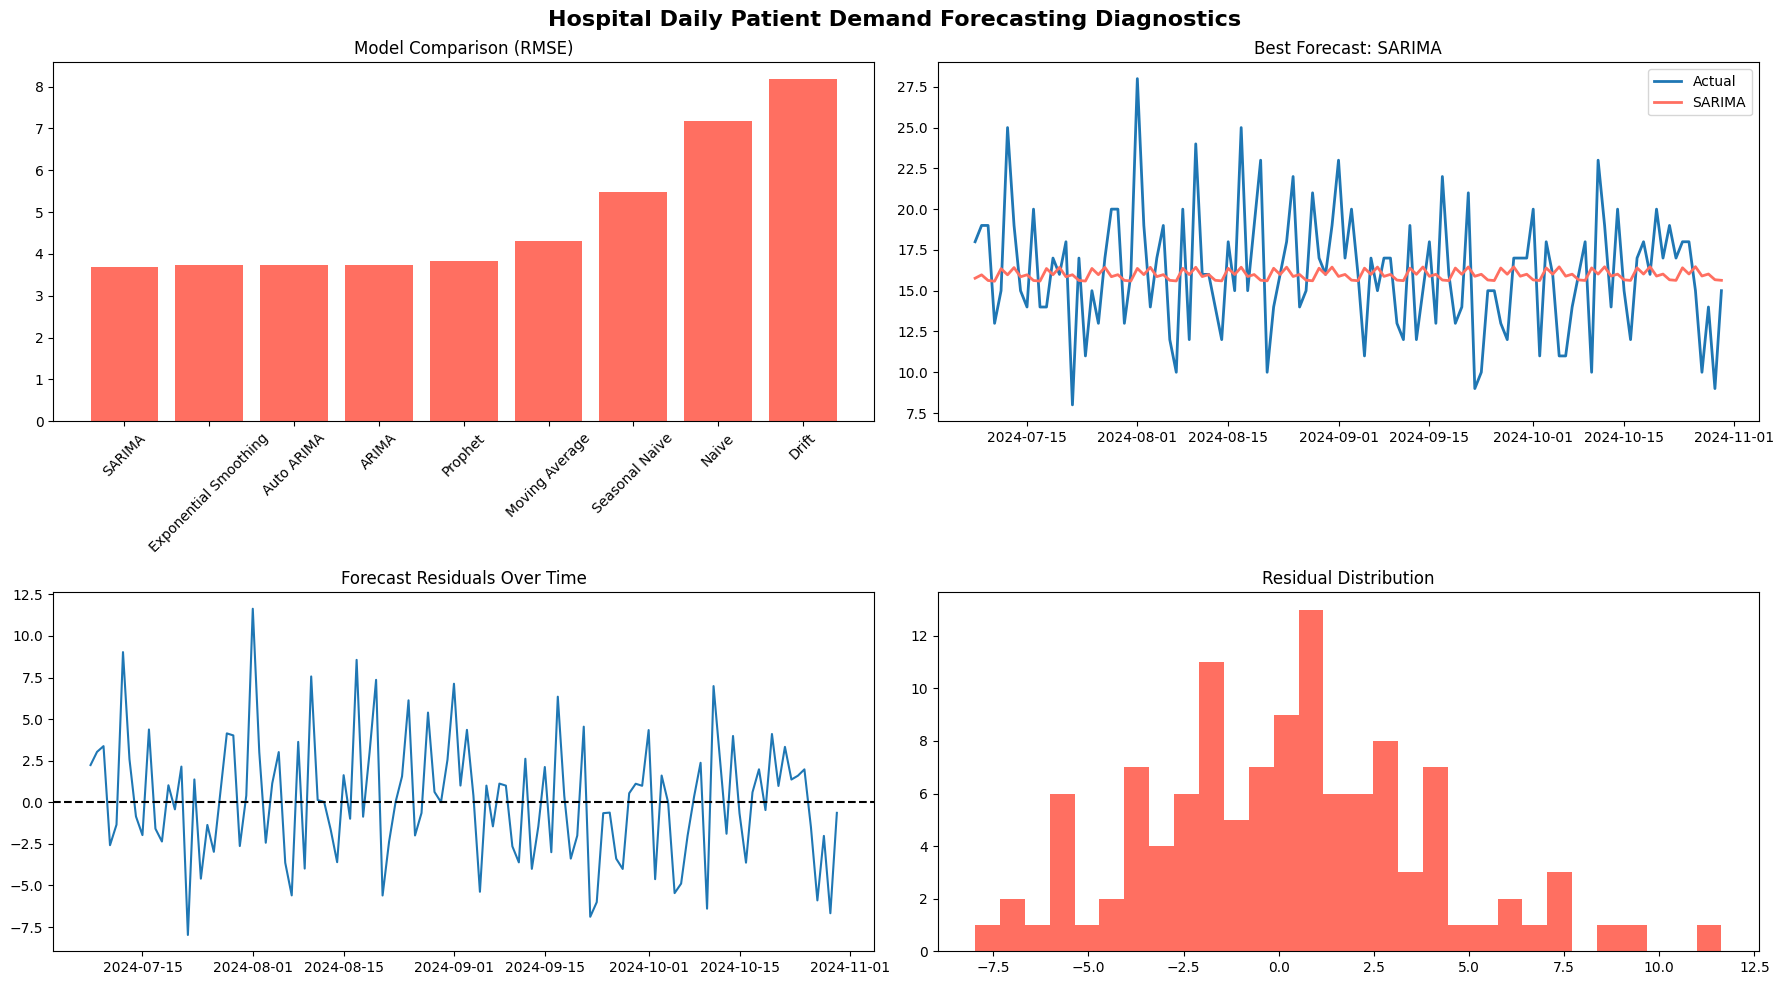

,Model,RMSE,MAE
0,SARIMA,3.692396,2.907992
1,Exponential Smoothing,3.728563,2.924161
2,Auto ARIMA,3.734808,2.939357
3,ARIMA,3.734958,2.939616
4,Prophet,3.838458,3.022261
5,Moving Average,4.298155,3.387931
6,Seasonal Naive,5.479586,4.215517
7,Naive,7.186554,6.215517
8,Drift,8.170099,7.315271


In [11]:
from visualization.explore_time import plot_time_diagnostics

# Collect model forecasts
forecasts = {
    "Naive": naive_results["forecast"],
    "Seasonal Naive": seasonal_naive_results["forecast"],
    "Moving Average": moving_average_results["forecast"],
    "Drift": drift_results["forecast"],
    "Exponential Smoothing": exponential_smoothing_results["forecast"],
    "ARIMA": arima_results["forecast"],
    "Auto ARIMA": auto_arima_results["forecast"],
    "SARIMA": sarima_results["forecast"],
    "Prophet": prophet_results["forecast"]
}

# Forecasting diagnostic dashboard
forecast_diagnostics = plot_time_diagnostics(
    y_true=test,
    forecasts=forecasts,
    selection_metric="RMSE",
    title="Hospital Daily Patient Demand Forecasting Diagnostics"
)

forecast_diagnostics["metrics"]

SARIMA achieved the best forecasting performance with the lowest RMSE and MAE values. However, the improvement compared with Exponential Smoothing and Auto ARIMA was marginal, indicating that hospital demand patterns are relatively stable and contain limited temporal complexity. Simpler forecasting approaches were insufficient, while highly flexible models such as Prophet did not provide additional predictive value. Therefore, SARIMA is selected as the preferred forecasting model for demand prediction.

## 5-Out-of-Sample Demand Forecast

In [12]:
# Generate demand forecast using selected model
final_model = sarima_forecast(
    train,
    test
)

future_forecast = final_model["forecast"]

future_forecast.head()

Admission Date
2024-07-07    15.764303
2024-07-08    15.971577
2024-07-09    15.625459
2024-07-10    15.581916
2024-07-11    16.348069
Name: predicted_mean, dtype: float64

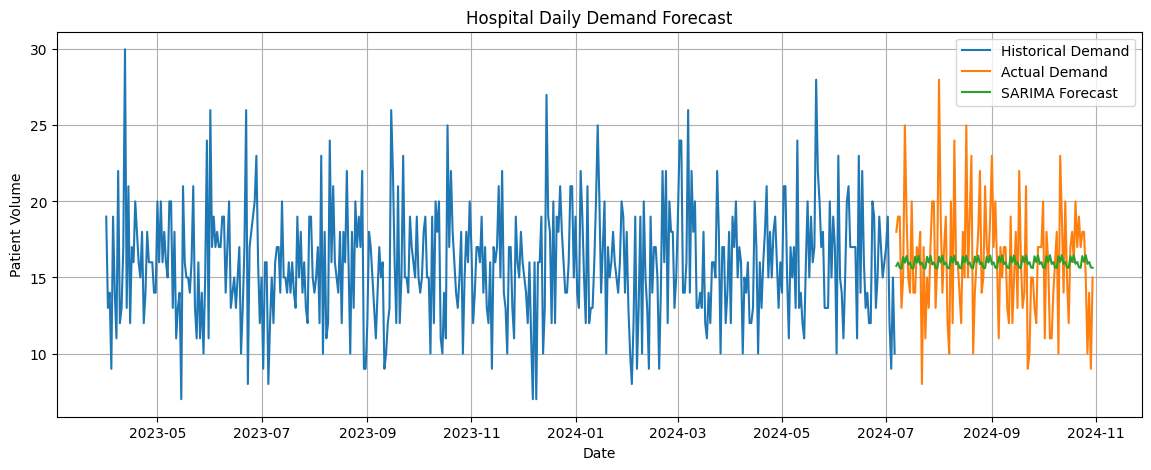

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(
    train.index,
    train,
    label="Historical Demand"
)

plt.plot(
    test.index,
    test,
    label="Actual Demand"
)

plt.plot(
    future_forecast.index,
    future_forecast,
    label="SARIMA Forecast"
)

plt.title(
    "Hospital Daily Demand Forecast"
)

plt.xlabel("Date")
plt.ylabel("Patient Volume")

plt.legend()
plt.grid(True)

plt.show()

The SARIMA model provides forecasts close to the average historical demand level, with smoother variations than the actual patient arrivals. This result is consistent with the previous time series analysis, which showed limited seasonality and weak temporal relationships. Although SARIMA achieved the best overall performance, the results suggest that additional operational variables may be needed to better explain daily demand variations.

## 6-Forecast Uncertainty Assessment

In [14]:
# Calculate forecast residuals

forecast_errors = (
    test - future_forecast
)

uncertainty_summary = pd.DataFrame({
    "Metric": [
        "Mean Error",
        "Error Standard Deviation",
        "Minimum Error",
        "Maximum Error"
    ],
    "Value": [
        forecast_errors.mean(),
        forecast_errors.std(),
        forecast_errors.min(),
        forecast_errors.max()
    ]
})

uncertainty_summary

,Metric,Value
0,Mean Error,0.161158
1,Error Standard Deviation,3.704882
2,Minimum Error,-7.977838
3,Maximum Error,11.634094


Forecast errors were analyzed to quantify the uncertainty associated with demand predictions. Residual variability provides an estimate of the uncertainty inherent in the forecasting process and helps characterize the expected variability of patient demand.

This forecasting approach was intentionally designed with a focused scope, prioritizing interpretability, robustness, and reliable model evaluation. More advanced extensions, such as incorporating external operational variables, probabilistic forecasting, rolling validation strategies, hierarchical forecasting, or machine learning-based approaches, could further improve predictive performance in future iterations. However, given the stability and limited temporal complexity observed in the current demand series, the selected SARIMA-based approach provides an appropriate balance between accuracy, transparency, and practical applicability.

## 7-Summary - Notebook 3

| Element                         | Objective                         | Methods / Tools                                                                         | Key Findings                                                                                                   | Decision Support Implications                                       |
| ------------------------------- | --------------------------------- | --------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------- |
| Time Series Validation          | Confirm forecasting readiness     | Frequency validation, missing value checks, statistical profiling                       | Daily demand series contained 579 complete observations without structural issues                              | Ensures reliable forecasting inputs                                 |
| Demand Pattern Analysis         | Identify temporal characteristics | Seasonality tests, stationarity tests, autocorrelation analysis                         | Demand was stable, stationary, and showed limited seasonal dependency                                          | Supports the selection of appropriate forecasting models            |
| Forecasting Model Evaluation    | Compare forecasting strategies    | Naive, Moving Average, Drift, ARIMA, Auto ARIMA, SARIMA, Prophet, Exponential Smoothing | SARIMA achieved the best performance with RMSE of 3.69, although improvements over simpler models were limited | Identifies the most appropriate model for demand forecasting |
| Forecast Uncertainty Assessment | Quantify prediction variability   | Residual analysis and forecast error measurement                                        | Forecast errors represent expected variability in demand                                                | Improves the interpretation of forecasting uncertainty              |


## 8-Limitations

| Limitation                            | Description                                                                                                                                                                                                  | Potential Improvement                                                                                                           |
| ------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------- |
| Univariate forecasting approach       | The forecasting models rely exclusively on historical patient demand and do not incorporate external explanatory variables such as holidays, weather conditions, epidemics, or hospital operational factors. | Develop multivariate forecasting models integrating relevant external predictors to improve forecasting accuracy.               |
| Single train-test split               | Model evaluation is based on one chronological train-test split, which may not fully capture forecasting performance under different time periods or demand conditions.                                      | Apply rolling-origin evaluation or time series cross-validation to obtain more robust performance estimates.                    |
| Point forecasting                     | The selected forecasting models generate point forecasts, while uncertainty is evaluated separately through residual analysis. Prediction intervals are not explicitly incorporated into decision-making.    | Implement probabilistic forecasting methods with prediction intervals or forecast distributions.                                |
| Limited forecasting horizon           | The analysis focuses on short-term out-of-sample forecasting and does not evaluate long-term forecasting performance.                                                                                        | Assess forecasting accuracy across multiple planning horizons to support both operational and strategic planning.               |
| Stable demand characteristics         | The historical demand series exhibits weak seasonality and limited temporal dependence, reducing the potential benefits of more sophisticated forecasting models.                                            | Validate the forecasting framework using more volatile datasets or demand series with stronger temporal dynamics.               |
| Limited feature engineering           | Temporal features such as holidays, weekdays, seasonal events, or special operational periods are not explicitly modeled.                                                                                    | Introduce calendar-based and operational features to better capture systematic demand variations.                               |
| Independent uncertainty assessment    | Forecast uncertainty is evaluated after model estimation through residual analysis and is not directly integrated into downstream planning or optimization models.                                           | Couple forecasting uncertainty with optimization using stochastic or scenario-based decision models.                            |
| Hypothetical decision-support context | The notebook demonstrates a forecasting methodology using an educational case study rather than supporting decisions in a live hospital environment.                                                         | Validate the forecasting framework using real-time hospital data and compare forecast performance under operational conditions. |


## 9-Data Export

In [15]:
forecast_output = pd.DataFrame({
    "Date": test.index,
    "Actual Demand": test.values,
    "Forecast Demand": future_forecast.values,
    "Forecast Error": forecast_errors.values
})

output_file = "hospital_demand_forecasting_results.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    forecast_diagnostics["metrics"].to_excel(
        writer,
        sheet_name="Model Performance",
        index=False
    )

    forecast_output.to_excel(
        writer,
        sheet_name="Demand Forecast",
        index=False
    )

    uncertainty_summary.to_excel(
        writer,
        sheet_name="Forecast Uncertainty",
        index=False
    )


print("Forecasting results exported successfully.")

Forecasting results exported successfully.
